In [1]:
import pandas as pd
import numpy as np
import warnings
import sys
from pandas.tseries.offsets import DateOffset

In [2]:
# --- IMPORT YOUR CUSTOM PLOTTER ---
sys.path.append("/Users/paretoadvisoryllc/Desktop/Pareto/Plot_Style_Configuration")
from pareto_linechart import pareto_linechart

warnings.filterwarnings("ignore")

# ========= USER CONFIG =========
months_to_plot = 24  # how many recent months to show

# Local path on your Mac (edit as needed):
file_path = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/CPB - Traveler and Conveyance Statistics.xlsx"

# Output figure paths
save_path_level = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CPB - Entries_Level.jpg"
save_path_mom   = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CBP - Entries_MoM.jpg"
save_path_yoy   = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CBP - Entries_YoY.jpg"
save_path_sum   = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CPB - Entries_12-Month Sum.jpg"

# Titles / notes (explicit RGV ports)
title_prefix_base = "CBP Entries — Total (Travelers + Conveyances, RGV Ports)"
source_text = (
    "Source: U.S. Customs and Border Protection (Traveler & Conveyance Statistics)\n"
    "Analysis by Nissi Cantu\n"
    "Notes: Port of Entry — Brownsville, TX; Hidalgo, TX; Progreso, TX; "
    "Rio Grande City, TX; Roma, TX; Valley International Airport"
)

In [3]:
# ========= LOAD =========
# Expecting columns EXACTLY: Date, Travelers, Conveyances
df = pd.read_excel(file_path, usecols=["Date", "Travelers", "Conveyances"])

# ---------- Clean & coerce ----------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for col in ["Travelers", "Conveyances"]:
    df[col] = (
        df[col]
          .astype(str)
          .str.replace(",", "", regex=False)
          .str.strip()
          .replace({"": np.nan})
          .pipe(pd.to_numeric, errors="coerce")
    )

df = df.dropna(subset=["Date"])

# If multiple rows per month (e.g., daily), aggregate to monthly sum
df = (
    df.assign(Period=df["Date"].dt.to_period("M"))
      .groupby("Period", as_index=False)[["Travelers", "Conveyances"]].sum()
      .assign(Date=lambda x: x["Period"].dt.to_timestamp(how="start"))
      .drop(columns="Period")
      .sort_values("Date")
      .set_index("Date")
      .asfreq("MS")  # enforce monthly continuity (month start)
)

# Fill any single-month gaps if present
for col in ["Travelers", "Conveyances"]:
    if df[col].isna().any():
        df[col] = df[col].interpolate("linear")

# ========= Combine into single series =========
df["Total Entries"] = df["Travelers"] + df["Conveyances"]

# Keep a protected, unscaled copy for tables
df["Total Entries (raw)"] = (df["Travelers"] + df["Conveyances"]).astype(float)

# ========= Rates =========
df["MoM %"] = df["Total Entries"].pct_change(1) * 100
df["YoY %"] = df["Total Entries"].pct_change(12) * 100

# ========= Rolling 12-Month Sum =========
df["12M Sum"] = df["Total Entries"].rolling(12, min_periods=1).sum()

# ========= Auto-scale units for Level + 12M Sum (avoid scientific notation) =========
max_val = float(np.nanmax([df["Total Entries"].max(), df["12M Sum"].max()]))

if max_val >= 1_000_000:
    scale_divisor = 1_000_000
    scale_label = "Entries (Millions)"
elif max_val >= 1_000:
    scale_divisor = 1_000
    scale_label = "Entries (Thousands)"
else:
    scale_divisor = 1
    scale_label = "Travelers"

df["Total Entries"] = df["Total Entries"] / scale_divisor
df["Entries (12-Month Sum)"] = df["12M Sum"] / scale_divisor

# ========= Trim for plotting window =========
last_obs = df.index.max()
cutoff = last_obs - DateOffset(months=months_to_plot)
plot_df = df[df.index > cutoff].copy()

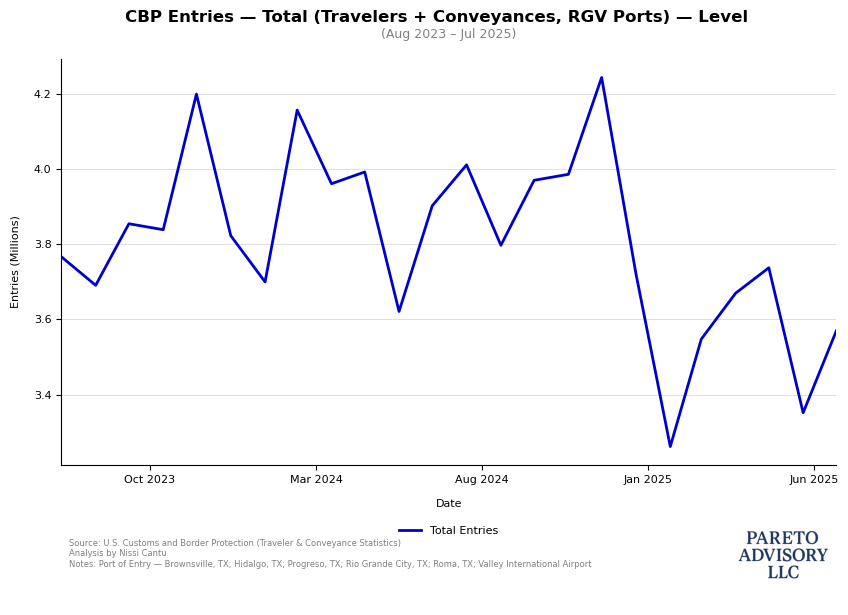

[PLOT SAVED] /Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CPB - Entries_Level.jpg


In [4]:
# ========= PLOTS =========
# Level (scaled, single line)
pareto_linechart(
    df=plot_df[["Total Entries"]],
    title_prefix=f"{title_prefix_base} — Level",
    ylabel=scale_label,  # human-readable units
    source_text=source_text,
    save_path=save_path_level
)
print(f"[PLOT SAVED] {save_path_level}")

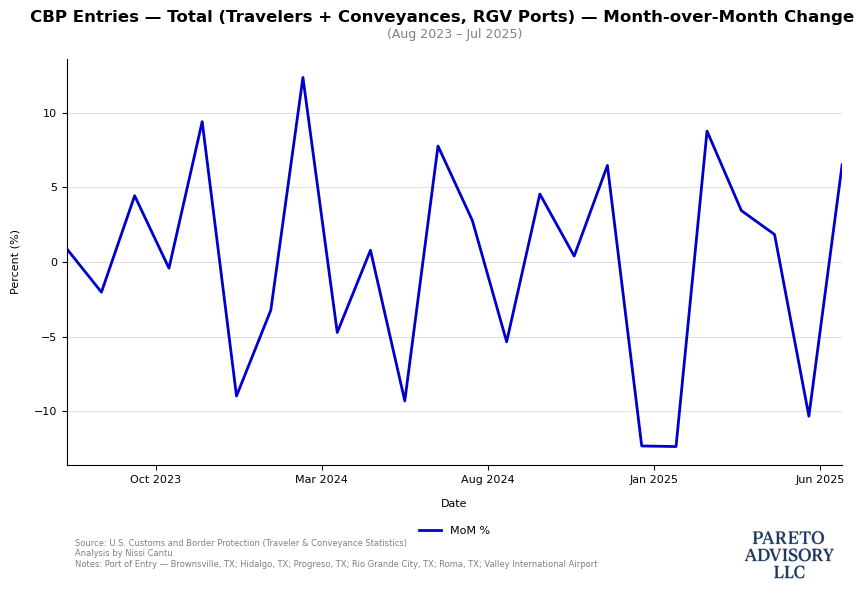

[PLOT SAVED] /Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CBP - Entries_MoM.jpg


In [5]:
# MoM (%) (single line)
pareto_linechart(
    df=plot_df[["MoM %"]],
    title_prefix=f"{title_prefix_base} — Month-over-Month Change",
    ylabel="Percent (%)",
    source_text=source_text,
    save_path=save_path_mom
)
print(f"[PLOT SAVED] {save_path_mom}")

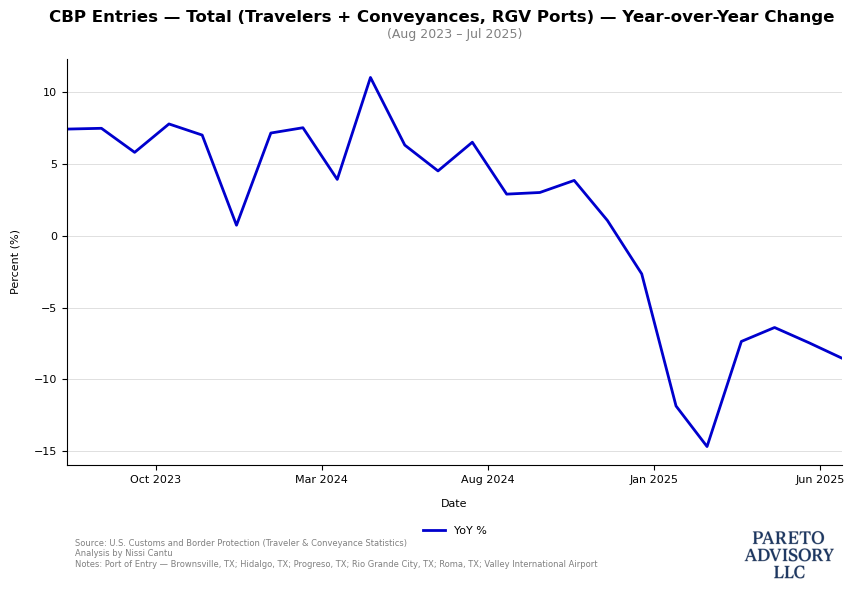

[PLOT SAVED] /Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CBP - Entries_YoY.jpg


In [6]:
# YoY (%) (single line)
pareto_linechart(
    df=plot_df[["YoY %"]],
    title_prefix=f"{title_prefix_base} — Year-over-Year Change",
    ylabel="Percent (%)",
    source_text=source_text,
    save_path=save_path_yoy
)
print(f"[PLOT SAVED] {save_path_yoy}")

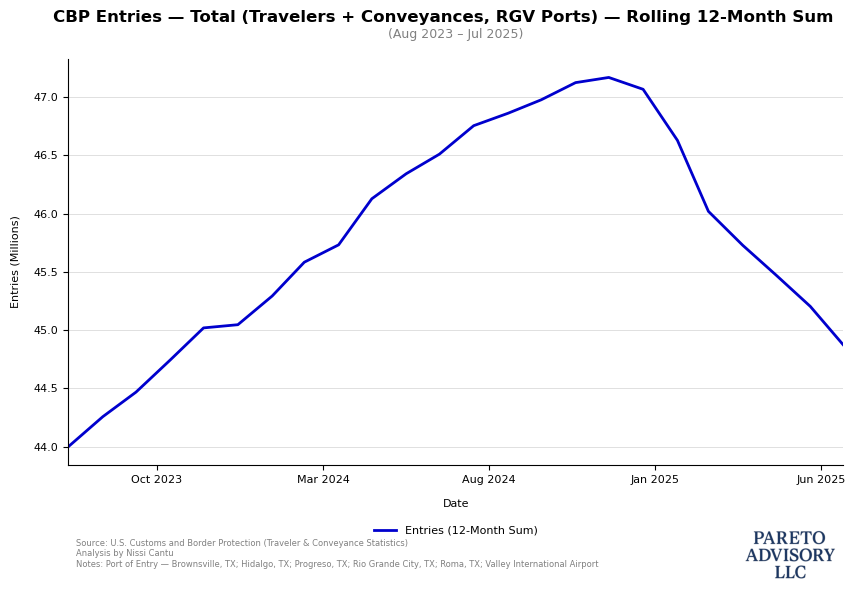

[PLOT SAVED] /Users/paretoadvisoryllc/Desktop/Pareto/Analysis/Local/Figures/CPB - Entries_12-Month Sum.jpg


In [7]:
# Rolling 12-Month Sum (scaled, single line)
pareto_linechart(
    df=plot_df[["Entries (12-Month Sum)"]],
    title_prefix=f"{title_prefix_base} — Rolling 12-Month Sum",
    ylabel=scale_label,  # human-readable units
    source_text=source_text,
    save_path=save_path_sum
)
print(f"[PLOT SAVED] {save_path_sum}")

In [8]:
# ========= Recent Table (last 12 months) =========
recent = df[["Total Entries (raw)", "MoM %", "YoY %"]].tail(12).copy()
recent = recent.rename(columns={"Total Entries (raw)": "Total Entries"})

print("\n=== Recent Total Entries (Travelers + Conveyances) ===")
print(
    recent.assign(
        **{
            "Total Entries": lambda x: x["Total Entries"].round(0).astype(int).map("{:,}".format),
            "MoM %": lambda x: x["MoM %"].round(2),
            "YoY %": lambda x: x["YoY %"].round(2),
        }
    ).to_string(index=True)
)


=== Recent Total Entries (Travelers + Conveyances) ===
           Total Entries  MoM %  YoY %
Date                                  
2024-08-01     4,011,637   2.79   6.50
2024-09-01     3,797,492  -5.34   2.89
2024-10-01     3,970,503   4.56   3.00
2024-11-01     3,986,411   0.40   3.84
2024-12-01     4,244,308   6.47   1.06
2025-01-01     3,721,495 -12.32  -2.66
2025-02-01     3,261,662 -12.36 -11.85
2025-03-01     3,547,676   8.77 -14.67
2025-04-01     3,669,927   3.45  -7.36
2025-05-01     3,737,656   1.85  -6.39
2025-06-01     3,351,705 -10.33  -7.45
2025-07-01     3,570,003   6.51  -8.53
